In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- CONFIGURAZIONE ---
STOCK = "NVDA"       # Il tuo titolo
INDICE = "SPY"       # L'indice di riferimento (S&P 500)
START_DATE = "2024-01-01"

print(f"--- Scarico dati per {STOCK} e {INDICE}... ---")

# 1. PRENDI I DATI (Scarichiamo entrambi insieme per allineare le date)
data = yf.download([STOCK, INDICE], start=START_DATE, progress=False)

# Pulizia: Prendiamo solo la chiusura (Close o Adj Close)
# yfinance restituisce un DataFrame con colonne tipo ('Close', 'NVDA')
try:
    df = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']
except KeyError:
    df = data # Fallback

# 2. CALCOLA I RENDIMENTI GIORNALIERI (%)
# Non possiamo confrontare i prezzi (es. 800$ vs 500$), dobbiamo confrontare le %
returns = df.pct_change().dropna()

# Definiamo X (L'Indice - Il Mercato) e y (Il Titolo)
X = returns[INDICE].values.reshape(-1, 1)  # Variabile Indipendente
y = returns[STOCK].values.reshape(-1, 1)   # Variabile Dipendente

# 3. CALCOLA LA REGRESSIONE
model = LinearRegression()
model.fit(X, y)

# Previsione della retta (per il grafico)
trend = model.predict(X)

# 4. ESTRAZIONE DATI (IL "BETA")
beta = float(model.coef_[0])  # La pendenza della retta
alpha = float(model.intercept_) # L'extra rendimento (Alpha)
r2 = float(model.score(X, y))   # La correlazione

print(f"\n--- RISULTATI: {STOCK} vs {INDICE} ---")
print(f"BETA (Rischio/Reattività): {beta:.4f}")
print(f" -> Se > 1: {STOCK} è più volatile del mercato (Aggressivo)")
print(f" -> Se < 1: {STOCK} è meno volatile del mercato (Difensivo)")
print(f"\nR-QUADRO (Correlazione): {r2:.4f}")
print(f" -> Quanto {STOCK} segue fedelmente {INDICE}")

# 5. GRAFICO SCATTER PLOT
plt.figure(figsize=(10, 6))

# Disegna i punti (ogni punto è un giorno)
plt.scatter(X, y, alpha=0.5, color='blue', label='Rendimenti Giornalieri')

# Disegna la linea di regressione (Il Beta)
plt.plot(X, trend, color='red', linewidth=2, label=f'Beta Line (pendenza={beta:.2f})')

plt.title(f"Analisi di Correlazione: {STOCK} vs {INDICE}")
plt.xlabel(f"Rendimenti {INDICE} (Mercato)")
plt.ylabel(f"Rendimenti {STOCK} (Titolo)")
plt.axhline(0, color='black', linewidth=0.5) # Linea dello zero orizzontale
plt.axvline(0, color='black', linewidth=0.5) # Linea dello zero verticale
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Scarico dati per NVDA e SPY... ---


TypeError: only 0-dimensional arrays can be converted to Python scalars

Pendenza (Coefficiente): 0.2212
Bontà del fit (R2): 0.8119


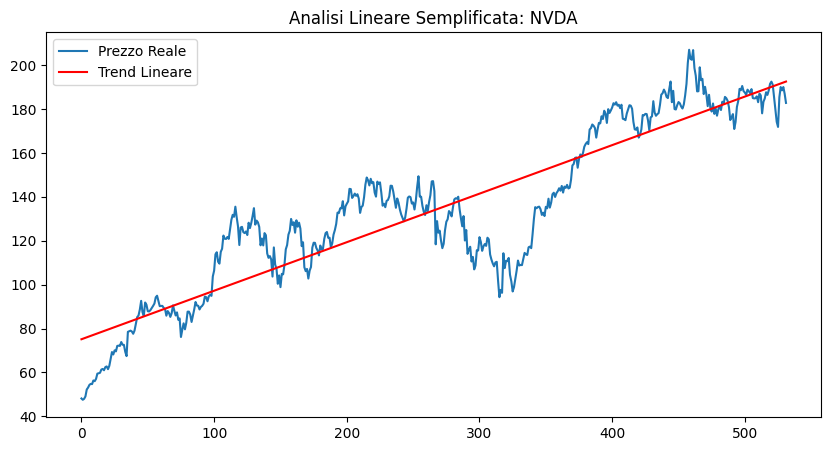

In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. PRENDI I DATI
# Scarichiamo NVDA dal 2024 a oggi
data = yf.download("NVDA", start="2024-01-01", progress=False)

# Pulizia: Prendiamo solo la colonna 'Close' e la trasformiamo in numeri semplici
y = data['Close'].values
if y.ndim > 1: y = y.flatten()  # Se yfinance fa i capricci con le dimensioni, appiattiamo tutto

# 2. PREPARA I NUMERI
# X sono i giorni (0, 1, 2, 3...)
X = np.arange(len(y)).reshape(-1, 1) 

# 3. CALCOLA LA REGRESSIONE
model = LinearRegression()
model.fit(X, y)

# Crea la linea del trend
trend = model.predict(X)

# 4. MOSTRA I RISULTATI
print(f"Pendenza (Coefficiente): {float(model.coef_[0]):.4f}")
print(f"Bontà del fit (R2): {float(model.score(X, y)):.4f}")

# 5. FAI IL GRAFICO
plt.figure(figsize=(10, 5))
plt.plot(y, label="Prezzo Reale")
plt.plot(trend, color='red', label="Trend Lineare")
plt.legend()
plt.title("Analisi Lineare Semplificata: NVDA")
plt.show()